# BESS-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the BESS-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the BESS-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the BESS-JPL model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [41]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [42]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from BESS_JPL import process_BESS_table, load_ECOv002_calval_BESS_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [43]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function. The resulting DataFrame is displayed for inspection.

In [44]:
input_df = load_ECOv002_calval_BESS_inputs()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,ball_berry_intercept_C3,KG_climate,CI,canopy_height_meters,COT,AOT,Ca,wind_speed_mps,vapor_gccm,ozone_cm
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.005267,3,0.282353,20.642902,0,0,400,0,0,0.3
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [45]:
processed = process_BESS_table(input_df)
processed

[2025-09-10 12:04:46 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:46 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:46 INFO] started extracting time from PT-JPL-SM input table
[2025-09-10 12:04:46 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-10 12:04:46 INFO] variable elevation_km min: 0.001 mean: 0.993 max: 3.504 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable Ta_C min: -14.605 mean: 22.322 max: 39.710 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable C4_fraction min: 0.000 mean: 0.296 max: 0.939 nan: 0.00% (nan)
[2025-09-10 12:04:46 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 max: 0

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,ozone_cm,GPP,GPP_daily,Rn_Wm2,Rn_soil_Wm2,Rn_canopy_Wm2,LE_Wm2,LE_soil_Wm2,LE_canopy_Wm2,G_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.3,16.306166,5.963702,543.574447,343.088141,200.486306,253.346657,69.342528,184.004129,37.045927
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.3,21.081704,8.623039,745.548400,568.929428,176.618973,225.765314,100.628336,125.136978,75.785976
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.3,19.984935,8.120491,797.080000,595.207535,201.872465,346.807840,210.893323,135.914517,77.675719
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.3,24.216487,10.357271,734.801476,539.752171,195.049305,336.703432,207.202548,129.500884,69.717555
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.3,21.872922,10.242349,600.127613,441.941830,158.185783,259.677956,140.032444,119.645512,57.794590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.3,0.492826,0.193133,235.343693,165.684047,69.659646,46.681268,41.487784,5.193484,29.244793
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.3,1.259612,0.882347,266.190619,190.262323,75.928297,42.918736,31.172926,11.745809,32.896598
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.3,3.360783,2.404805,405.659567,266.716370,138.943197,47.368643,6.239409,41.129234,35.811898
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.3,1.986428,1.197719,314.897562,247.995207,66.902355,59.134543,48.996907,10.137635,44.868324


## Accuracy Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation

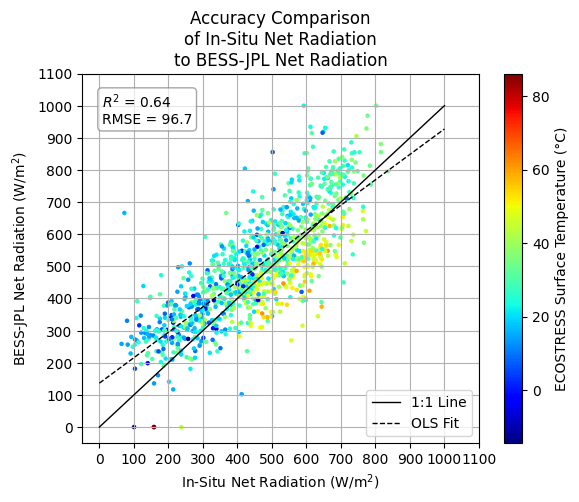

In [75]:
sc = plt.scatter(
    x=processed.NETRAD_filt,
    y=processed.Rn_Wm2,
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Add 1-to-1 line
min_val = min(processed.NETRAD_filt.min(), processed.Rn_Wm2.min())
max_val = max(processed.NETRAD_filt.max(), processed.Rn_Wm2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed.NETRAD_filt, processed.Rn_Wm2, 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed.Rn_Wm2
y_pred = coefs[0] * processed.NETRAD_filt + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.95), xycoords='axes fraction',
             ha='left', va='top',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Net Radiation (W/m$^2$)")
plt.ylabel("BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Accuracy Comparison\nof In-Situ Net Radiation\nto BESS-JPL Net Radiation")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend()
plt.savefig("Unperturbed Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')
plt.show()

## Accuracy Comparison of In-Situ Net Radiation to BESS-JPL Latent Heat Flux

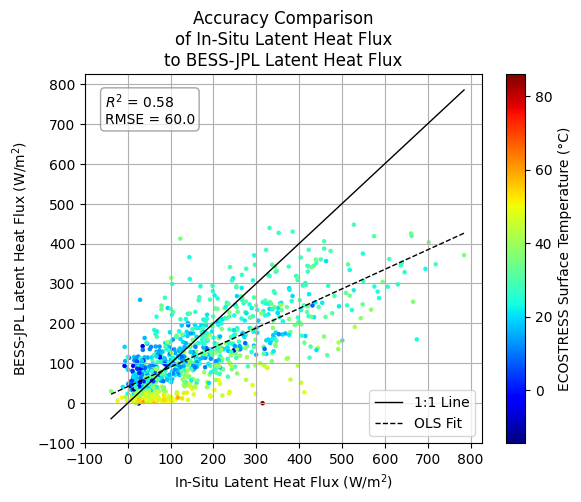

In [84]:
sc = plt.scatter(
    x=processed.LEcorr50,
    y=processed.LE_Wm2,
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Add 1-to-1 line
min_val = min(processed.LEcorr50.min(), processed.LE_Wm2.min())
max_val = max(processed.LEcorr50.max(), processed.LE_Wm2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed.LEcorr50, processed.LE_Wm2, 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed.LE_Wm2
y_pred = coefs[0] * processed.LEcorr50 + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.95), xycoords='axes fraction',
             ha='left', va='top',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Latent Heat Flux (W/m$^2$)")
plt.ylabel("BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Accuracy Comparison\nof In-Situ Latent Heat Flux\nto BESS-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend()
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')
plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Net Radiation

This cell creates a scatter plot comparing ECOSTRESS surface temperature to BESS-JPL net radiation for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

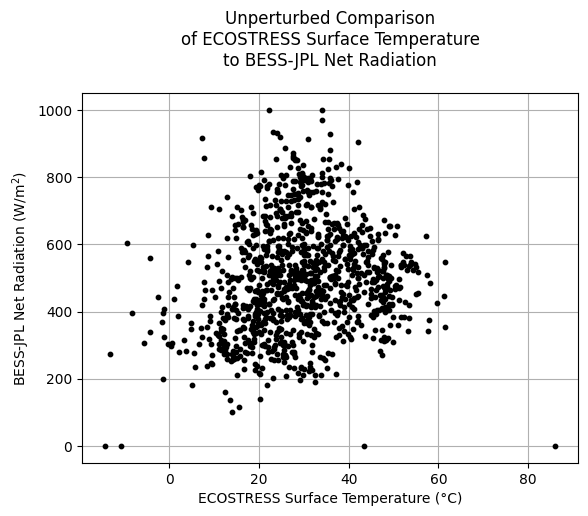

In [72]:
plt.scatter(x=processed.ST_C, y=processed.Rn_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto BESS-JPL Net Radiation", pad=20)

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

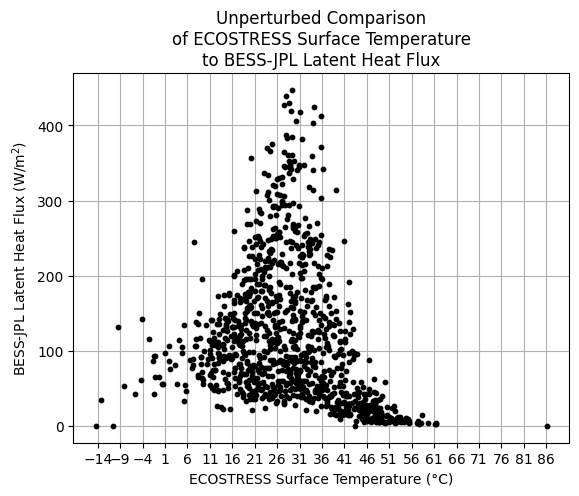

In [47]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.LE_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Further Filter Input Data and Check Temperature Range

This cell applies additional filters to the input data, ensuring only valid `fAPARmax` and `NDVI` values are included. It also checks the minimum and maximum surface temperature values in the filtered dataset.

In [48]:
# input_df = pd.read_csv(input_filename)
input_df = load_ECOv002_calval_BESS_inputs()

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

np.nanmin(input_df.ST_C), np.nanmax(input_df.ST_C)

(np.float64(-13.189999999999998), np.float64(86.11000000000001))

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [49]:
len(input_df)

1063

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the BESS-JPL model. The results are displayed for further analysis.

In [50]:
input_variable = "ST_C"
output_variable = "Rn_Wm2"

Rn_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

Rn_results

[2025-09-10 12:04:47 INFO] tarting Monte Carlo perturbed run
[2025-09-10 12:04:47 INFO] calculating standard deviation of input variable: ST_C
[2025-09-10 12:04:47 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-10 12:04:47 INFO] starting forward process
[2025-09-10 12:04:47 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:47 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:47 INFO] started extracting time from PT-JPL-SM input table
[2025-09-10 12:04:47 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-10 12:04:47 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-10 12:04:47 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-10 12:04:47 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-10 12:04:47 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,Rn_Wm2,31.95,-2.253758,0.070540,29.696242,543.574447,53.184595,0.097842,596.759042
1,ST_C,Rn_Wm2,31.95,5.718437,0.178981,37.668437,543.574447,-92.314558,0.169829,451.259889
2,ST_C,Rn_Wm2,31.95,17.107795,0.535455,49.057795,543.574447,-280.313245,0.515685,263.261202
3,ST_C,Rn_Wm2,31.95,4.176365,0.130716,36.126365,543.574447,-67.287422,0.123787,476.287025
4,ST_C,Rn_Wm2,31.95,21.189021,0.663193,53.139021,543.574447,-342.856263,0.630744,200.718184
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,Rn_Wm2,41.61,0.652349,0.015678,42.262349,621.777597,-11.594881,0.018648,610.182716
106296,ST_C,Rn_Wm2,41.61,6.517019,0.156621,48.127019,621.777597,-117.030238,0.188219,504.747359
106297,ST_C,Rn_Wm2,41.61,-3.352935,0.080580,38.257065,621.777597,59.183527,0.095184,680.961124
106298,ST_C,Rn_Wm2,41.61,3.475616,0.083528,45.085616,621.777597,-62.080977,0.099844,559.696620


In [51]:
input_variable = "ST_C"
output_variable = "LE_Wm2"

LE_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

LE_results

[2025-09-10 12:04:55 INFO] tarting Monte Carlo perturbed run
[2025-09-10 12:04:55 INFO] calculating standard deviation of input variable: ST_C
[2025-09-10 12:04:55 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-10 12:04:55 INFO] starting forward process
[2025-09-10 12:04:55 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:55 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-10 12:04:55 INFO] started extracting time from PT-JPL-SM input table
[2025-09-10 12:04:55 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-10 12:04:55 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-10 12:04:55 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-10 12:04:55 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-10 12:04:55 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,-3.892944,0.121845,28.057056,253.346657,21.305291,0.084095,274.651948
1,ST_C,LE_Wm2,31.95,-0.605066,0.018938,31.344934,253.346657,5.569469,0.021984,258.916126
2,ST_C,LE_Wm2,31.95,-2.325339,0.072781,29.624661,253.346657,17.769297,0.070138,271.115955
3,ST_C,LE_Wm2,31.95,-3.421982,0.107104,28.528018,253.346657,20.555255,0.081135,273.901912
4,ST_C,LE_Wm2,31.95,-19.357610,0.605872,12.59239,253.346657,-24.256488,0.095744,229.090170
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,16.805638,0.403885,58.415638,40.483396,-24.418667,0.603177,16.064729
106296,ST_C,LE_Wm2,41.61,-1.828233,0.043937,39.781767,40.483396,8.785588,0.217017,49.268984
106297,ST_C,LE_Wm2,41.61,-21.141687,0.508091,20.468313,40.483396,42.016832,1.037878,82.500227
106298,ST_C,LE_Wm2,41.61,-2.344954,0.056356,39.265046,40.483396,11.416197,0.281997,51.899592


## Filter Out NaN Results

This cell removes any rows with missing values from the perturbed results to ensure only valid data points are used in subsequent analysis and plotting.

In [52]:
filtered_Rn_results = Rn_results.dropna()
filtered_Rn_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,Rn_Wm2,31.95,-2.253758,0.070540,29.696242,543.574447,53.184595,0.097842,596.759042
1,ST_C,Rn_Wm2,31.95,5.718437,0.178981,37.668437,543.574447,-92.314558,0.169829,451.259889
2,ST_C,Rn_Wm2,31.95,17.107795,0.535455,49.057795,543.574447,-280.313245,0.515685,263.261202
3,ST_C,Rn_Wm2,31.95,4.176365,0.130716,36.126365,543.574447,-67.287422,0.123787,476.287025
4,ST_C,Rn_Wm2,31.95,21.189021,0.663193,53.139021,543.574447,-342.856263,0.630744,200.718184
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,Rn_Wm2,41.61,0.652349,0.015678,42.262349,621.777597,-11.594881,0.018648,610.182716
106296,ST_C,Rn_Wm2,41.61,6.517019,0.156621,48.127019,621.777597,-117.030238,0.188219,504.747359
106297,ST_C,Rn_Wm2,41.61,-3.352935,0.080580,38.257065,621.777597,59.183527,0.095184,680.961124
106298,ST_C,Rn_Wm2,41.61,3.475616,0.083528,45.085616,621.777597,-62.080977,0.099844,559.696620


In [53]:
filtered_LE_results = LE_results.dropna()
filtered_LE_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,-3.892944,0.121845,28.057056,253.346657,21.305291,0.084095,274.651948
1,ST_C,LE_Wm2,31.95,-0.605066,0.018938,31.344934,253.346657,5.569469,0.021984,258.916126
2,ST_C,LE_Wm2,31.95,-2.325339,0.072781,29.624661,253.346657,17.769297,0.070138,271.115955
3,ST_C,LE_Wm2,31.95,-3.421982,0.107104,28.528018,253.346657,20.555255,0.081135,273.901912
4,ST_C,LE_Wm2,31.95,-19.357610,0.605872,12.59239,253.346657,-24.256488,0.095744,229.090170
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,16.805638,0.403885,58.415638,40.483396,-24.418667,0.603177,16.064729
106296,ST_C,LE_Wm2,41.61,-1.828233,0.043937,39.781767,40.483396,8.785588,0.217017,49.268984
106297,ST_C,LE_Wm2,41.61,-21.141687,0.508091,20.468313,40.483396,42.016832,1.037878,82.500227
106298,ST_C,LE_Wm2,41.61,-2.344954,0.056356,39.265046,40.483396,11.416197,0.281997,51.899592


## Plot Change in Surface Temperature vs Net Radiation

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL net radiation due to input perturbations. The plot is saved as JPEG and SVG files.

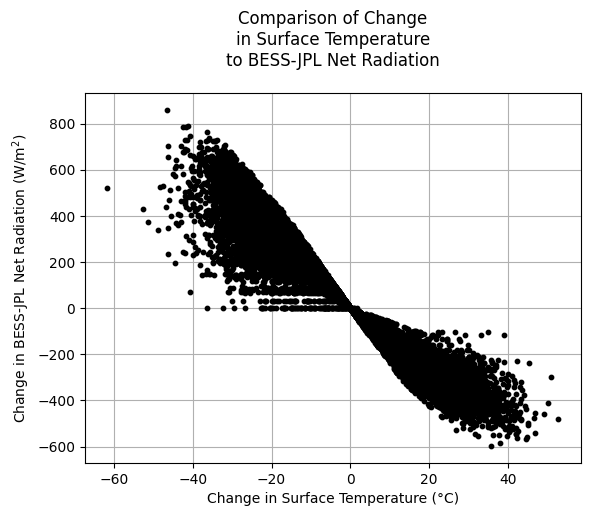

In [54]:
# plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
# plt.ylim(-350, 150)
plt.scatter(x=Rn_results.input_perturbation, y=Rn_results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)

plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

In [55]:
Rn_results.columns

Index(['input_variable', 'output_variable', 'input_unperturbed',
       'input_perturbation', 'input_perturbation_std', 'input_perturbed',
       'output_unperturbed', 'output_perturbation', 'output_perturbation_std',
       'output_perturbed'],
      dtype='object')

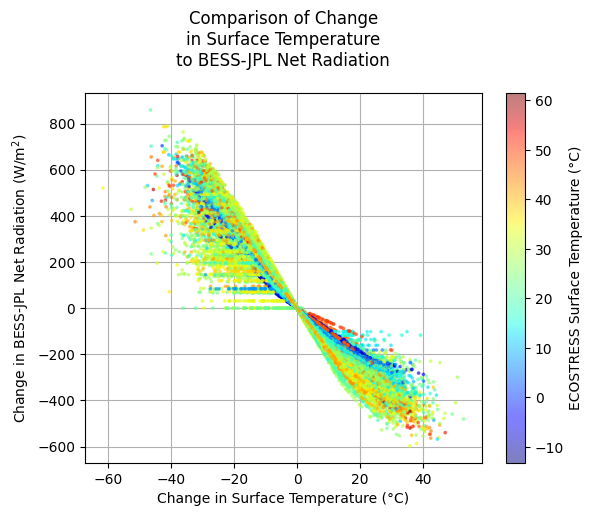

In [71]:
sc = plt.scatter(
    x=Rn_results.input_perturbation, 
    y=Rn_results.output_perturbation, 
    c=Rn_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

In [57]:
# ST_Rn_aggregated_perturbation = Rn_results.groupby("input_unperturbed")["output_perturbation"].mean().reset_index()
# ST_Rn_aggregated_perturbation

In [58]:
# sc = plt.scatter(
#     x=Rn_results.input_unperturbed, 
#     y=Rn_results.output_perturbation, 
#     color="Black",
#     s=10, 
#     zorder=5
# )

# plt.grid(True, zorder=0)
# plt.xlabel("ECOSTRESS Surface Temperature (°C)")
# plt.ylabel("Average Change in BESS-JPL Net Radiation (W/m$^2$)")
# plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)
# plt.savefig("Comparison of Surface Temperature to Change in BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
# plt.savefig("Comparison of Surface Temperature to Change in BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

# plt.show()

## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

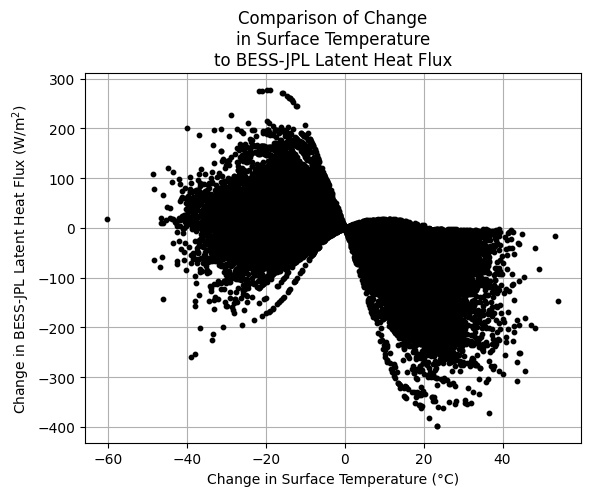

In [66]:
plt.scatter(x=LE_results.input_perturbation, y=LE_results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

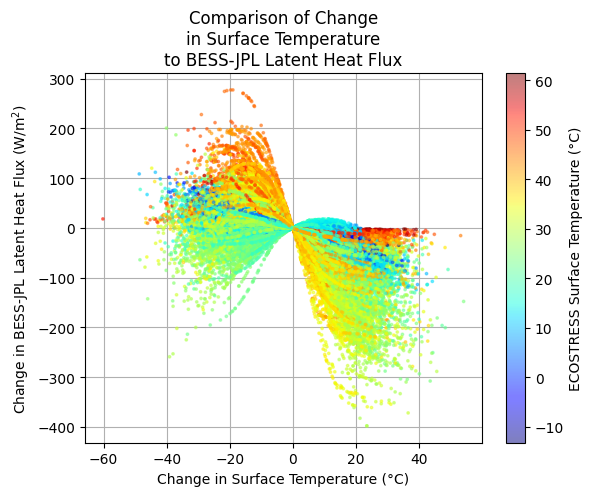

In [70]:
sc = plt.scatter(
    x=LE_results.input_perturbation, 
    y=LE_results.output_perturbation, 
    c=LE_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [60]:
correlation = mstats.pearsonr(
    np.array(filtered_Rn_results.input_perturbation_std).astype(np.float64), 
    np.array(filtered_Rn_results.output_perturbation_std).astype(np.float64)
)[0]

correlation

np.float64(0.1400911936557959)

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [78]:
input_variables = ["ST_C", "albedo", "Ta_C", "RH"]
output_variables = ["Rn_Wm2"]

Rn_perturbation_df, Rn_sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

Rn_sensitivity_metrics_df

[2025-09-10 12:26:50 INFO] tarting Monte Carlo perturbed run
[2025-09-10 12:26:50 INFO] calculating standard deviation of input variable: ST_C
[2025-09-10 12:26:50 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-10 12:26:50 INFO] starting forward process
[2025-09-10 12:26:50 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-10 12:26:50 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-10 12:26:50 INFO] started extracting time from PT-JPL-SM input table
[2025-09-10 12:26:50 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-10 12:26:50 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-10 12:26:50 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-10 12:26:50 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-10 12:26:50 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09

/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perturbation_df = pd.concat([perturbation_df, run_results])
/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sensitivity_metrics_df = pd.concat([sensitivity_metrics_df, pd.DataFrame([[


[2025-09-10 12:26:59 INFO] variable canopy_height_meters min: 0.000 mean: 6.055 max: 30.192 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable Ca (float64) with [400.] unique values
[2025-09-10 12:26:59 INFO] * 400.0: 1063
[2025-09-10 12:26:59 INFO] variable wind_speed_mps (float64) with [7.4] unique values
[2025-09-10 12:26:59 INFO] * 7.4: 1063
[2025-09-10 12:26:59 WARNING] netrc credentials not found for daac.ornl.gov
[2025-09-10 12:26:59 INFO] variable Ps_Pa min: 64923.167 mean: 90406.157 max: 101313.196 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable VPD_Pa min: 9.430 mean: 1745.964 max: 4717.745 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable RH min: 0.273 mean: 0.426 max: 0.985 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable desTa min: 16.249 mean: 177.138 max: 387.676 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable ddesTa min: 1.197 mean: 9.183 max: 17.906 nan: 0.00% (nan)
[2025-09-10 12:26:59 INFO] variable gamma min: 42.603 mean: 60.196 max: 68.164 nan: 0

/Users/halverso/Projects/BESS-JPL/BESS_JPL/meteorology.py:166: RuntimeWarning: invalid value encountered in sqrt
  epsa0 = 0.605 + 0.048 * (Ea_Pa / 100) ** 0.5  # [-]


[2025-09-10 12:27:25 INFO] variable APAR_sunlit min: 109.936 mean: 389.925 max: 1449.779 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable APAR_shaded min: 1.718 mean: 33.330 max: 154.003 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable ASW_sunlit min: 75.260 mean: 206.407 max: 516.332 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable ASW_shaded min: 0.722 mean: 17.210 max: 163.527 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable ASW_soil min: 54.380 mean: 464.405 max: 790.805 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable G min: 0.791 mean: 56.293 max: 99.512 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable GPP_C3 min: 0.000 mean: 8.884 max: 40.000 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable LE_C3 min: 0.000 mean: 120.820 max: 664.228 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable LE_soil_C3 min: 0.000 mean: 63.394 max: 446.175 nan: 0.00% (nan)
[2025-09-10 12:27:25 INFO] variable LE_canopy_C3 min: 0.000 mean: 57.426 max: 381.876 nan: 0.00% (nan)


/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: divide by zero encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]
/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:123: RuntimeWarning: divide by zero encountered in divide
  rs = 1.0 / (gs1 / cf * 1e-2)  # [s m-1]
/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: invalid value encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]


[2025-09-10 12:27:25 INFO] completed forward process for perturbed input
[2025-09-10 12:27:25 INFO] normalizing output perturbations
[2025-09-10 12:27:25 INFO] Monte Carlo run complete


,input_variable,output_variable,metric,value
0,ST_C,Rn_Wm2,correlation,0.143660
0,ST_C,Rn_Wm2,r2,0.020638
0,ST_C,Rn_Wm2,mean_normalized_change,0.344407
0,albedo,Rn_Wm2,correlation,0.615646
0,albedo,Rn_Wm2,r2,0.379021
0,albedo,Rn_Wm2,mean_normalized_change,0.059138
0,Ta_C,Rn_Wm2,correlation,0.063398
0,Ta_C,Rn_Wm2,r2,0.004019
0,Ta_C,Rn_Wm2,mean_normalized_change,0.240062
0,RH,Rn_Wm2,correlation,0.460726


In [80]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["LE_Wm2"]

LE_perturbation_df, LE_sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

LE_sensitivity_metrics_df

[2025-09-10 12:50:29 INFO] tarting Monte Carlo perturbed run
[2025-09-10 12:50:29 INFO] calculating standard deviation of input variable: ST_C
[2025-09-10 12:50:29 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-10 12:50:29 INFO] starting forward process
[2025-09-10 12:50:29 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-10 12:50:29 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-10 12:50:29 INFO] started extracting time from PT-JPL-SM input table
[2025-09-10 12:50:29 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-10 12:50:29 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-10 12:50:29 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-10 12:50:29 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-10 12:50:29 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09

/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perturbation_df = pd.concat([perturbation_df, run_results])
/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sensitivity_metrics_df = pd.concat([sensitivity_metrics_df, pd.DataFrame([[


[2025-09-10 12:50:38 INFO] variable RVIS min: 0.015 mean: 0.108 max: 0.300 nan: 0.00% (nan)
[2025-09-10 12:50:38 INFO] variable RNIR min: 0.015 mean: 0.108 max: 0.300 nan: 0.00% (nan)
[2025-09-10 12:50:38 INFO] variable PARDir min: 111.324 mean: 305.988 max: 491.893 nan: 0.00% (nan)
[2025-09-10 12:50:38 INFO] variable KG_climate (float32) with [1. 2. 3. 4. 5.] unique values
[2025-09-10 12:50:38 INFO] * 1.0: 3
[2025-09-10 12:50:38 INFO] * 2.0: 473
[2025-09-10 12:50:38 INFO] * 3.0: 172
[2025-09-10 12:50:38 INFO] * 4.0: 411
[2025-09-10 12:50:38 INFO] * 5.0: 4
[2025-09-10 12:50:38 INFO] variable canopy_height_meters min: 0.000 mean: 6.055 max: 30.192 nan: 0.00% (nan)
[2025-09-10 12:50:38 INFO] variable Ca (float64) with [400.] unique values
[2025-09-10 12:50:38 INFO] * 400.0: 1063
[2025-09-10 12:50:38 INFO] variable wind_speed_mps (float64) with [7.4] unique values
[2025-09-10 12:50:38 INFO] * 7.4: 1063
[2025-09-10 12:50:38 WARNING] netrc credentials not found for daac.ornl.gov
[2025-09-10

/Users/halverso/Projects/BESS-JPL/BESS_JPL/LAI_from_NDVI.py:26: RuntimeWarning: divide by zero encountered in log
  LAI = rt.clip(-np.log(1 - fIPAR) * (1 / KPAR), min_LAI, max_LAI)


[2025-09-10 12:50:46 INFO] variable G min: 0.000 mean: 51.925 max: 107.773 nan: 13.50% (nan)
[2025-09-10 12:50:46 INFO] variable GPP_C3 min: 0.000 mean: 10.521 max: 40.000 nan: 13.50% (nan)
[2025-09-10 12:50:46 INFO] variable LE_C3 min: 0.000 mean: 112.612 max: 527.381 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable LE_soil_C3 min: 0.000 mean: 50.736 max: 282.789 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable LE_canopy_C3 min: 0.000 mean: 61.876 max: 484.131 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable Rn_C3 min: 0.000 mean: 441.118 max: 1000.000 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable Rn_soil_C3 min: 0.000 mean: 312.063 max: 774.371 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable Rn_canopy_C3 min: 0.000 mean: 129.095 max: 740.048 nan: 0.00% (nan)
[2025-09-10 12:50:46 INFO] variable GPP_C4 min: 0.000 mean: 15.993 max: 50.000 nan: 13.50% (nan)
[2025-09-10 12:50:46 INFO] variable LE_C4 min: 0.000 mean: 117.331 max: 610.715 nan: 0.00% (nan)
[2025-09-10

/Users/halverso/Projects/BESS-JPL/BESS_JPL/meteorology.py:166: RuntimeWarning: invalid value encountered in sqrt
  epsa0 = 0.605 + 0.048 * (Ea_Pa / 100) ** 0.5  # [-]


[2025-09-10 12:51:13 INFO] variable I_NSoil min: 51.784 mean: 316.871 max: 530.806 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable ANIR_Soil min: 36.249 mean: 221.810 max: 371.564 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable Q_NSunUp min: 8.884 mean: 90.758 max: 153.486 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable Q_NShUp min: 0.206 mean: 4.303 max: 24.887 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable ANIR_Sun min: 47.061 mean: 120.604 max: 203.977 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable ANIR_Sh min: 0.213 mean: 8.929 max: 130.415 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable G min: 0.791 mean: 56.293 max: 99.512 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable sunlit_fraction min: 0.118 mean: 0.240 max: 0.580 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable APAR_sunlit min: 109.936 mean: 389.925 max: 1449.779 nan: 0.00% (nan)
[2025-09-10 12:51:13 INFO] variable APAR_shaded min: 1.718 mean: 33.330 max: 154.003 nan: 0.00% (nan)
[20

/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: divide by zero encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]
/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: invalid value encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]
/Users/halverso/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:123: RuntimeWarning: divide by zero encountered in divide
  rs = 1.0 / (gs1 / cf * 1e-2)  # [s m-1]


[2025-09-10 12:51:14 INFO] completed forward process for perturbed input
[2025-09-10 12:51:14 INFO] normalizing output perturbations
[2025-09-10 12:51:14 INFO] Monte Carlo run complete


,input_variable,output_variable,metric,value
0,ST_C,LE_Wm2,correlation,0.019461
0,ST_C,LE_Wm2,r2,0.000379
0,ST_C,LE_Wm2,mean_normalized_change,0.400697
0,NDVI,LE_Wm2,correlation,0.642537
0,NDVI,LE_Wm2,r2,0.412853
0,NDVI,LE_Wm2,mean_normalized_change,0.390490
0,albedo,LE_Wm2,correlation,0.501476
0,albedo,LE_Wm2,r2,0.251478
0,albedo,LE_Wm2,mean_normalized_change,0.044223
0,Ta_C,LE_Wm2,correlation,0.025018


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the BESS-JPL label.

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_4644/1152039436.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


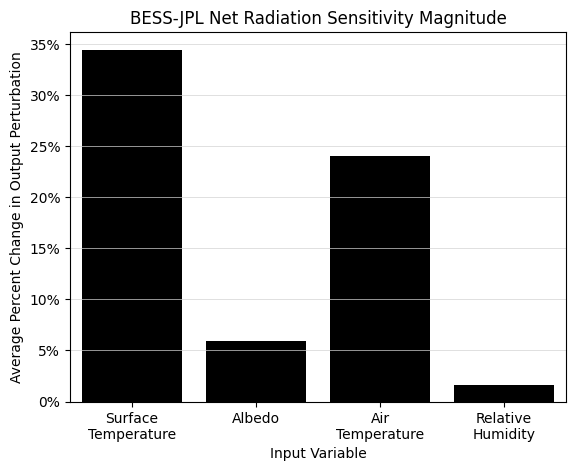

In [79]:
df = Rn_sensitivity_metrics_df
df = df[(df.output_variable == "Rn_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("BESS-JPL Net Radiation Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("BESS-JPL Net Radiation Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Net Radiation Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

/var/folders/hk/35_x93nx79vg1zmd2fy1vcbr0000gq/T/ipykernel_4644/3947530048.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


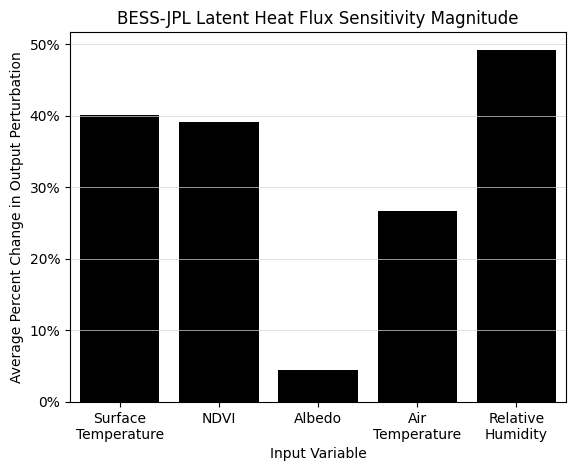

In [81]:
df = LE_sensitivity_metrics_df
df = df[(df.output_variable == "LE_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("BESS-JPL Latent Heat Flux Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the BESS-JPL model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.